<a href="https://colab.research.google.com/github/Muskan2326/DataScience-ML/blob/main/BitCoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the Bitcoin Market Sentiment Dataset
sentiment_df = pd.read_csv('/content/fear_greed_index.csv')
print("Bitcoin Market Sentiment Dataset (fear_greed_index.csv) loaded successfully.")

display(sentiment_df.head())

Bitcoin Market Sentiment Dataset (fear_greed_index.csv) loaded successfully.


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
# Load the Historical Trader Data from Hyperliquid
trader_data_df = pd.read_csv('/content/historical_data (1).csv')
print("Historical Trader Data (historical_data (1).csv) loaded successfully.")

display(trader_data_df.head())

Historical Trader Data (historical_data (1).csv) loaded successfully.


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
print("\n--- Sentiment DataFrame Info ---")
sentiment_df.info()
print("\n--- Sentiment DataFrame Description ---")
display(sentiment_df.describe(include='all'))


--- Sentiment DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

--- Sentiment DataFrame Description ---


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


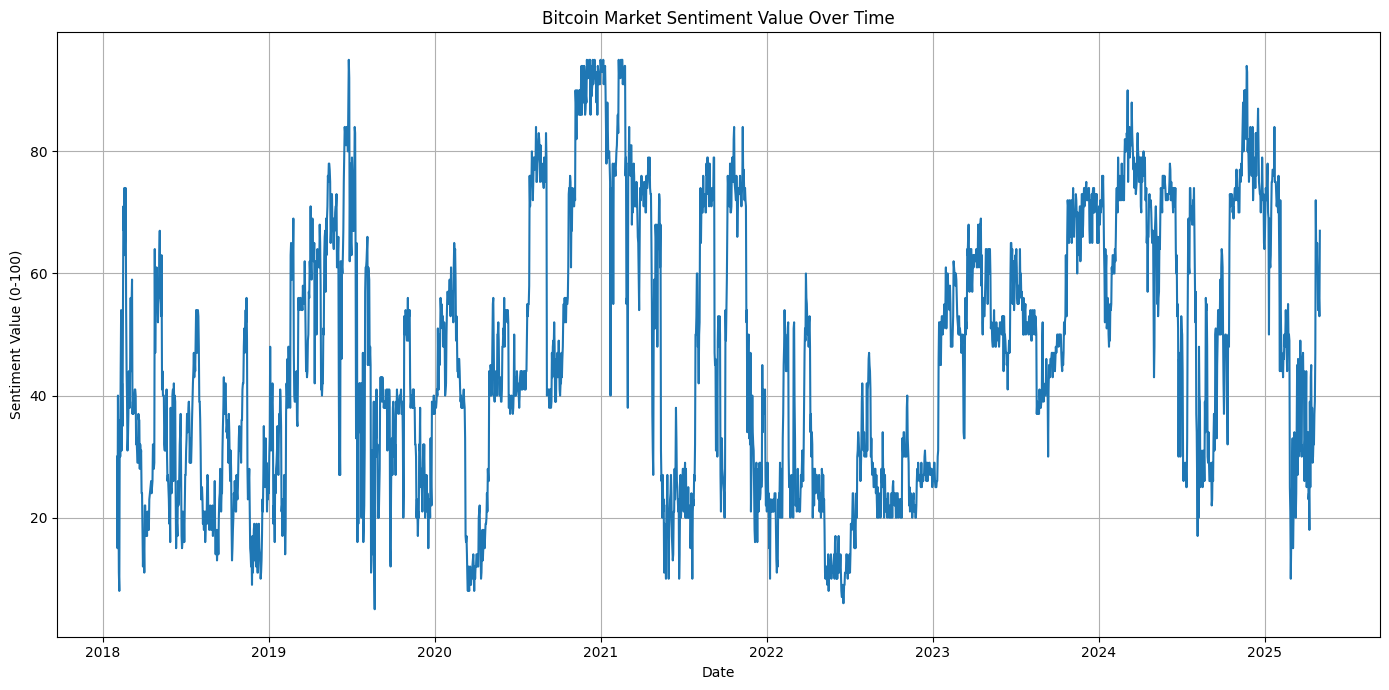

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'date' column to datetime objects
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

# Sort by date to ensure correct plotting order
sentiment_df = sentiment_df.sort_values(by='date')

# Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='value', data=sentiment_df)
plt.title('Bitcoin Market Sentiment Value Over Time')
plt.xlabel('Date')
plt.ylabel('Sentiment Value (0-100)')
plt.grid(True)
plt.tight_layout()
plt.show()

       Sentiment    avg_pnl     total_pnl  win_rate     avg_size
0   Extreme Fear  34.537862  7.391102e+05  0.370607  5349.731843
1  Extreme Greed  67.892861  2.715171e+06  0.464943  3112.251565
2           Fear  54.290400  3.357155e+06  0.420768  7816.109931
3          Greed  42.743559  2.150129e+06  0.384828  5736.884375
4        Neutral  34.307718  1.292921e+06  0.396991  4782.732661


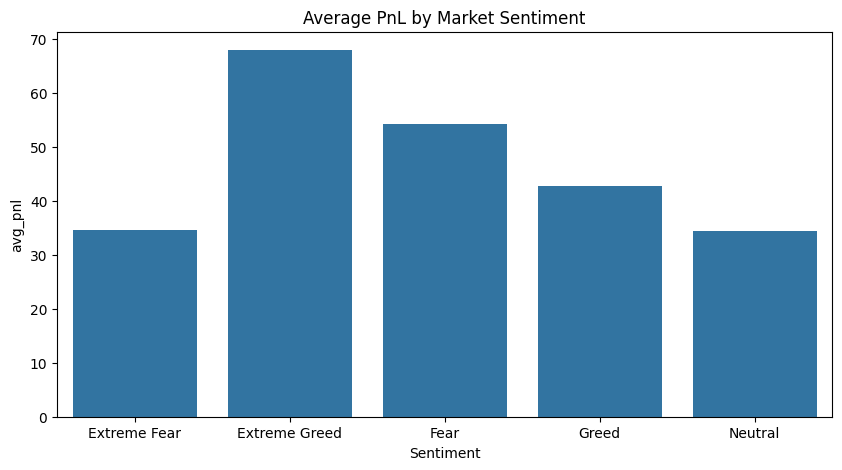

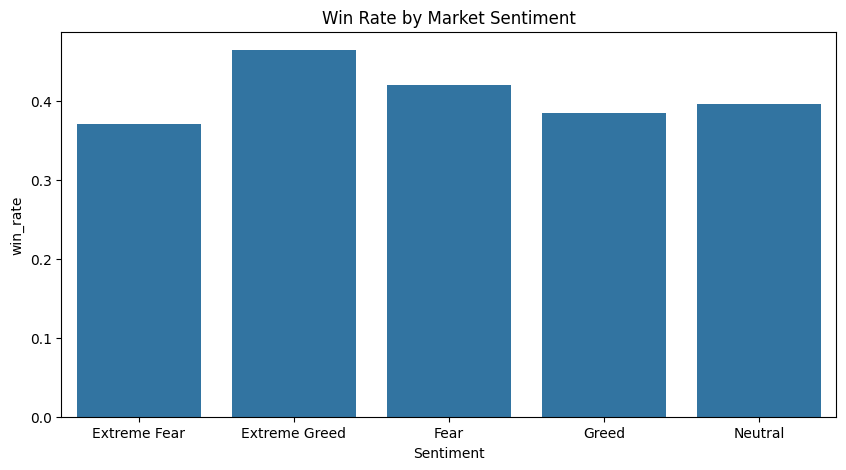

       Sentiment position_type  Closed PnL
0   Extreme Fear          Long   34.114627
1   Extreme Fear         Short   34.980106
2  Extreme Greed          Long   10.498927
3  Extreme Greed         Short  114.584643
4           Fear          Long   63.927104
5           Fear         Short   45.049641
6          Greed          Long   25.002302
7          Greed         Short   59.691091
8        Neutral          Long   29.227429
9        Neutral         Short   39.456408
            Closed PnL  abs_size
Closed PnL    1.000000  0.123645
abs_size      0.123645  1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

trader_data_df['Date'] = pd.to_datetime(trader_data_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

sentiment_df.rename(columns={'date': 'Date'}, inplace=True)
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.date # Convert to date-only to match trader_data_df['Date']

# 3. MERGE DATASETS
# Merge on the common 'Date' column
df = trader_data_df.merge(sentiment_df, on='Date', how='left')

# Drop missing sentiment rows. The sentiment information comes from the 'classification' column in sentiment_df.
df = df.dropna(subset=['classification'])

# Rename classification to Sentiment for consistency with later code
df.rename(columns={'classification': 'Sentiment'}, inplace=True)

# 4. FEATURE ENGINEERING
# Profitability flag. 'Closed PnL' is the correct column name.
df['is_profit'] = df['Closed PnL'] > 0

# Trade size absolute. 'Size USD' seems like the intended 'size'.
df['abs_size'] = df['Size USD'].abs()

# Long/Short. 'Side' is the correct column name.
df['position_type'] = df['Side'].apply(lambda x: 'Long' if x.lower() == 'buy' else 'Short')

# 5. AGGREGATIONS
summary = df.groupby('Sentiment').agg({
    'Closed PnL': ['mean', 'sum'], # Use 'Closed PnL'
    'is_profit': 'mean',
    'abs_size': 'mean'
}).reset_index()

summary.columns = ['Sentiment', 'avg_pnl', 'total_pnl', 'win_rate', 'avg_size']
print(summary)

# 6. VISUALIZATION
plt.figure(figsize=(10,5))
sns.barplot(data=summary, x='Sentiment', y='avg_pnl')
plt.title("Average PnL by Market Sentiment")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=summary, x='Sentiment', y='win_rate')
plt.title("Win Rate by Market Sentiment")
plt.show()

# 7. BEHAVIOR ANALYSIS
# Trades per sentiment
trade_count = df['Sentiment'].value_counts()

# Long vs Short profitability
ls_summary = df.groupby(['Sentiment', 'position_type'])['Closed PnL'].mean().reset_index() # Use 'Closed PnL'

print(ls_summary)

# 8. ADVANCED INSIGHTS

# Correlation
corr = df[['Closed PnL', 'abs_size']].corr() # Use 'Closed PnL'
print(corr)
